<a href="https://colab.research.google.com/github/SandhuruT/Data_Science_01/blob/main/Data_Science_project_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score


# Load the CSV using pandas and display the first 5 rows using .head()

df_sales = pd.read_csv('/content/retail_sales.csv')
df_sales.head()

,order_id,order_date,customer_id,customer_name,age,gender,city,category,product_name,quantity,unit_price,discount_pct,payment_method,returned
0,1001,2023-01-05,C201,Aarav Shah,28,Male,Mumbai,Electronics,Wireless Earbuds,1,2999,10,UPI,No
1,1002,2023-01-07,C045,Priya Nair,34,Female,Bangalore,Clothing,Silk Saree,2,1500,5,Credit Card,No
2,1003,2023-01-10,C312,Rohan Mehta,22,Male,Delhi,Books,Data Science Handbook,3,499,0,Debit Card,No
3,1004,2023-01-12,C078,Sneha Kulkarni,45,Female,Pune,Home & Kitchen,Air Fryer,1,4500,15,Credit Card,No
4,1005,2023-01-15,C201,Aarav Shah,28,Male,Mumbai,Electronics,Phone Case,2,299,0,UPI,No


In [2]:
df_sales.shape

(100, 14)

In [3]:
df_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   order_id        100 non-null    int64 
 1   order_date      100 non-null    object
 2   customer_id     100 non-null    object
 3   customer_name   100 non-null    object
 4   age             100 non-null    int64 
 5   gender          100 non-null    object
 6   city            100 non-null    object
 7   category        100 non-null    object
 8   product_name    100 non-null    object
 9   quantity        100 non-null    int64 
 10  unit_price      100 non-null    int64 
 11  discount_pct    100 non-null    int64 
 12  payment_method  100 non-null    object
 13  returned        100 non-null    object
dtypes: int64(5), object(9)
memory usage: 11.1+ KB


In [4]:
df_sales['order_date'] = pd.to_datetime(df_sales['order_date'])
df_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        100 non-null    int64         
 1   order_date      100 non-null    datetime64[ns]
 2   customer_id     100 non-null    object        
 3   customer_name   100 non-null    object        
 4   age             100 non-null    int64         
 5   gender          100 non-null    object        
 6   city            100 non-null    object        
 7   category        100 non-null    object        
 8   product_name    100 non-null    object        
 9   quantity        100 non-null    int64         
 10  unit_price      100 non-null    int64         
 11  discount_pct    100 non-null    int64         
 12  payment_method  100 non-null    object        
 13  returned        100 non-null    object        
dtypes: datetime64[ns](1), int64(5), object(8)
memory usage: 11.

In [5]:
# Check shape, data types, and missing values using .info() and .isnull().sum()
df_sales.isnull().sum()

,0
order_id,0
order_date,0
customer_id,0
customer_name,0
age,0
gender,0
city,0
category,0
product_name,0
quantity,0


In [6]:
# Add a new column revenue = quantity × unit_price × (1 − discount_pct/100)
df_sales['revenue'] = df_sales['quantity']*df_sales['unit_price']*(1-df_sales['discount_pct']/100)
df_sales

,order_id,order_date,customer_id,customer_name,age,gender,city,category,product_name,quantity,unit_price,discount_pct,payment_method,returned,revenue
0,1001,2023-01-05,C201,Aarav Shah,28,Male,Mumbai,Electronics,Wireless Earbuds,1,2999,10,UPI,No,2699.1
1,1002,2023-01-07,C045,Priya Nair,34,Female,Bangalore,Clothing,Silk Saree,2,1500,5,Credit Card,No,2850.0
2,1003,2023-01-10,C312,Rohan Mehta,22,Male,Delhi,Books,Data Science Handbook,3,499,0,Debit Card,No,1497.0
3,1004,2023-01-12,C078,Sneha Kulkarni,45,Female,Pune,Home & Kitchen,Air Fryer,1,4500,15,Credit Card,No,3825.0
4,1005,2023-01-15,C201,Aarav Shah,28,Male,Mumbai,Electronics,Phone Case,2,299,0,UPI,No,598.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,1096,2023-12-03,C067,Kavya Sharma,23,Female,Jaipur,Electronics,Drone Mini,1,11999,20,Credit Card,No,9599.2
96,1097,2023-12-07,C156,Vikram Iyer,31,Male,Chennai,Clothing,Winter Jacket,1,3500,15,Credit Card,No,2975.0
97,1098,2023-12-11,C312,Rohan Mehta,22,Male,Delhi,Home & Kitchen,Dishwasher,1,35000,25,EMI,No,26250.0
98,1099,2023-12-15,C845,Pooja Desai,33,Female,Surat,Beauty,Perfume Set,1,3200,10,Credit Card,No,2880.0


In [7]:
df_sales['revenue'].sum()

np.float64(394398.85)

In [8]:
df_sales[['product_name','quantity','unit_price','discount_pct','revenue']].head()

,product_name,quantity,unit_price,discount_pct,revenue
0,Wireless Earbuds,1,2999,10,2699.1
1,Silk Saree,2,1500,5,2850.0
2,Data Science Handbook,3,499,0,1497.0
3,Air Fryer,1,4500,15,3825.0
4,Phone Case,2,299,0,598.0


In [9]:
# Find the top 3 categories by total revenue using groupby

df_sales.groupby('category')['revenue'].sum().sort_values(ascending=False).head(3)

,revenue
category,
Electronics,176298.25
Home & Kitchen,122507.40
Clothing,55142.00


In [10]:
# Find which city placed the most orders and which city spent the most money
df_sales.groupby('city').size().sort_values(ascending=False).head(3)

,0
city,
Delhi,9
Mumbai,9
Chennai,8


In [11]:
df_sales.groupby('city')['revenue'].sum().sort_values(ascending=False).head(3)

,revenue
city,
Indore,76426.50
Kolkata,49214.85
Delhi,41981.15


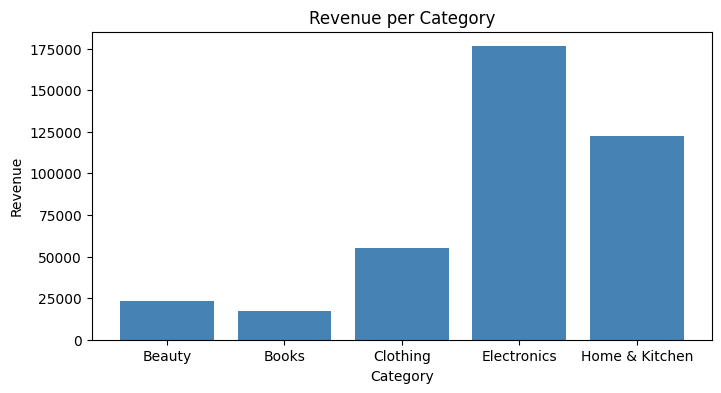

In [12]:
# Plot a bar chart of revenue by category and a monthly revenue trend line
import matplotlib.pyplot as plt

catagory_revenue = df_sales.groupby('category')['revenue'].sum()

plt.figure(figsize = (8,4))
plt.bar(catagory_revenue.index,catagory_revenue.values,color = 'steelblue')
plt.title('Revenue per Category')
plt.xlabel('Category')
plt.ylabel('Revenue')
plt.show()

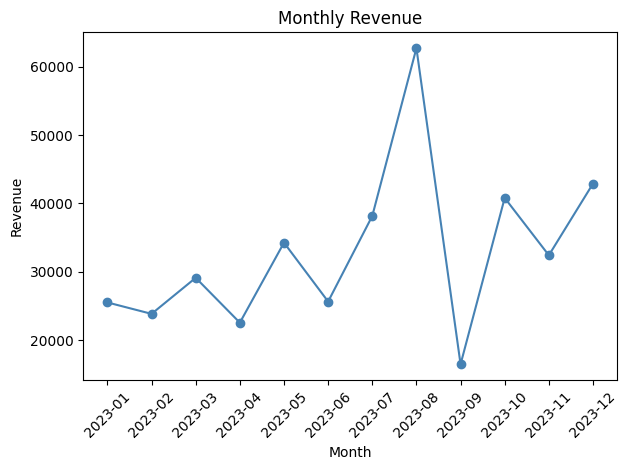

In [13]:
df_sales['mounth'] = df_sales['order_date'].dt.to_period('M')
momthlt_revenu = df_sales.groupby('mounth')['revenue'].sum()

plt.fiqure = figsize = (1,4)
plt.plot(momthlt_revenu.index.astype(str),momthlt_revenu.values,marker = 'o',color = 'steelblue')
plt.title('Monthly Revenue')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<Axes: xlabel='category', ylabel='revenue'>

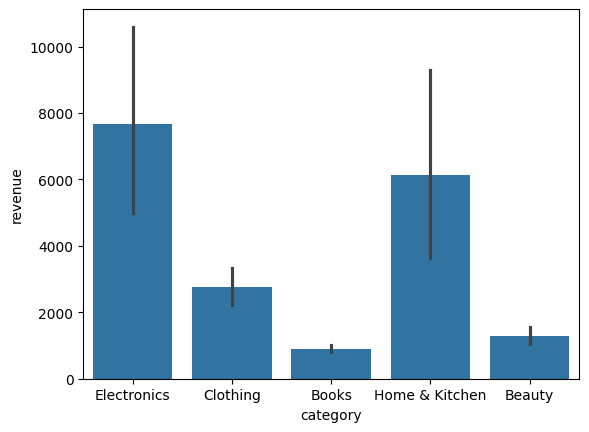

In [14]:
df_sales['revenue'] = df_sales['quantity'] * df_sales['unit_price'] * (1 - df_sales['discount_pct'] / 100)
sns.barplot(x='category',y='revenue',data=df_sales)

<Axes: xlabel='category', ylabel='revenue'>

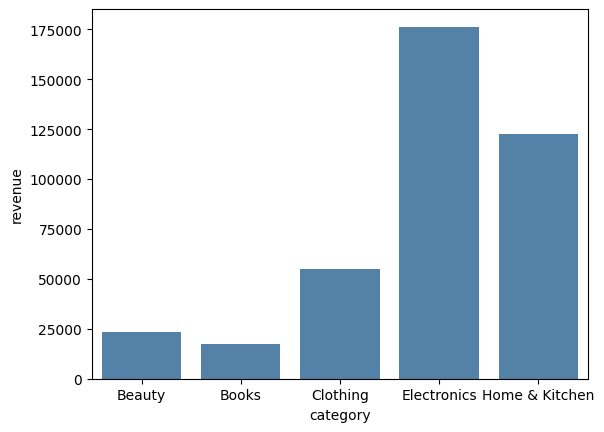

In [15]:
category_revenue_df = df_sales.groupby('category')['revenue'].sum().reset_index()
sns.barplot(x='category', y='revenue', data=category_revenue_df, color='steelblue')

In [16]:
# What % of orders were returned? Break it down by category
over_all = df_sales['returned'].map({'Yes': 1, 'No': 0}).mean()*100
over_all

np.float64(4.0)

In [17]:
print(f"Overall return rate: {over_all:.2f}%")

Overall return rate: 4.00%


In [18]:
df_sales.groupby('category')['returned'].apply(lambda x: (x == 'Yes').mean() * 100)

,returned
category,
Beauty,5.555556
Books,0.000000
Clothing,0.000000
Electronics,4.347826
Home & Kitchen,10.000000


In [19]:
df_sales.head(3)

,order_id,order_date,customer_id,customer_name,age,gender,city,category,product_name,quantity,unit_price,discount_pct,payment_method,returned,revenue,mounth
0,1001,2023-01-05,C201,Aarav Shah,28,Male,Mumbai,Electronics,Wireless Earbuds,1,2999,10,UPI,No,2699.1,2023-01
1,1002,2023-01-07,C045,Priya Nair,34,Female,Bangalore,Clothing,Silk Saree,2,1500,5,Credit Card,No,2850.0,2023-01
2,1003,2023-01-10,C312,Rohan Mehta,22,Male,Delhi,Books,Data Science Handbook,3,499,0,Debit Card,No,1497.0,2023-01


In [20]:
# Top 5 highest spending customers by total revenue. Write the code and paste the output.
df_sales.groupby('customer_name')['revenue'].sum().sort_values(ascending=False).head(5)

,revenue
customer_name,
Manish Tiwari,76426.50
Suresh Kumar,49214.85
Rohan Mehta,41981.15
Sneha Kulkarni,36145.85
Rahul Gupta,33610.40


## Machine Learning   (Feature Engineering)

In [21]:
# Machine Learning   (Feature Engineering)

features = ['category', 'gender', 'city', 'payment_method',
            'quantity', 'unit_price', 'discount_pct', 'revenue']

In [22]:
df_sales.head()

,order_id,order_date,customer_id,customer_name,age,gender,city,category,product_name,quantity,unit_price,discount_pct,payment_method,returned,revenue,mounth
0,1001,2023-01-05,C201,Aarav Shah,28,Male,Mumbai,Electronics,Wireless Earbuds,1,2999,10,UPI,No,2699.1,2023-01
1,1002,2023-01-07,C045,Priya Nair,34,Female,Bangalore,Clothing,Silk Saree,2,1500,5,Credit Card,No,2850.0,2023-01
2,1003,2023-01-10,C312,Rohan Mehta,22,Male,Delhi,Books,Data Science Handbook,3,499,0,Debit Card,No,1497.0,2023-01
3,1004,2023-01-12,C078,Sneha Kulkarni,45,Female,Pune,Home & Kitchen,Air Fryer,1,4500,15,Credit Card,No,3825.0,2023-01
4,1005,2023-01-15,C201,Aarav Shah,28,Male,Mumbai,Electronics,Phone Case,2,299,0,UPI,No,598.0,2023-01


In [23]:
X = df_sales[features].copy()
Y = df_sales['returned']

In [24]:
# Encoding text columns

X = pd.get_dummies(X,columns=['category','city','gender','payment_method'])

In [25]:
X.shape

(100, 32)

In [26]:
X.columns.tolist  # list all column name

<bound method IndexOpsMixin.tolist of Index(['quantity', 'unit_price', 'discount_pct', 'revenue', 'category_Beauty',
       'category_Books', 'category_Clothing', 'category_Electronics',
       'category_Home & Kitchen', 'city_Ahmedabad', 'city_Bangalore',
       'city_Bhopal', 'city_Chennai', 'city_Delhi', 'city_Hyderabad',
       'city_Indore', 'city_Jaipur', 'city_Kochi', 'city_Kolkata',
       'city_Lucknow', 'city_Mumbai', 'city_Nagpur', 'city_Pune', 'city_Surat',
       'gender_Female', 'gender_Male', 'payment_method_Cash',
       'payment_method_Credit Card', 'payment_method_Debit Card',
       'payment_method_EMI', 'payment_method_Net Banking',
       'payment_method_UPI'],
      dtype='object')>

### Trsin / Test Split

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size = 0.2, random_state = 42)

In [28]:
print(f"training rowes : {len(X_train)}")
print(f"testing rowes : {len(X_test)}")

training rowes : 80
testing rowes : 20


In [29]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state = 42)
model.fit(X_train,Y_train)

print("Model trained succssfully")
print(f"Number of leaves: {model.get_n_leaves()}")  # number of path through the trees
print(f"Tree depth: {model.get_depth()}")   # number of question asked

Model trained succssfully
Number of leaves: 8
Tree depth: 5


### Evaluate the Model

In [30]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
y_pred = model.predict(X_test)

print(f"Accuracy: {accuracy_score(Y_test,y_pred) *100:2f}%")
print("Classification Report:")
print(classification_report(Y_test,y_pred))
print("Confusion Matrix:")
print(confusion_matrix(Y_test,y_pred))

Accuracy: 85.000000%
Classification Report:
              precision    recall  f1-score   support

          No       0.94      0.89      0.92        19
         Yes       0.00      0.00      0.00         1

    accuracy                           0.85        20
   macro avg       0.47      0.45      0.46        20
weighted avg       0.90      0.85      0.87        20

Confusion Matrix:
[[17  2]
 [ 1  0]]


In [31]:
model_balanced = DecisionTreeClassifier(random_state=42, class_weight='balanced')
model_balanced.fit(X_train, y_train)

y_pred_balanced = model_balanced.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred_balanced) * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_balanced))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_balanced))

NameError: name 'y_train' is not defined

In [32]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load and prepare data
df_sales = pd.read_csv('/content/retail_sales.csv')
df_sales['order_date'] = pd.to_datetime(df_sales['order_date'])
df_sales['revenue'] = df_sales['quantity'] * df_sales['unit_price'] * (1 - df_sales['discount_pct'] / 100)
df_sales['returned'] = (df_sales['returned'] == 'Yes').astype(int)

# Feature engineering
features = ['category', 'gender', 'city', 'payment_method',
            'quantity', 'unit_price', 'discount_pct', 'revenue']
X = df_sales[features].copy()
y = df_sales['returned']
X = pd.get_dummies(X, columns=['category', 'gender', 'city', 'payment_method'])

# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Balanced model
model_balanced = DecisionTreeClassifier(random_state=42, class_weight='balanced')
model_balanced.fit(X_train, y_train)
y_pred_balanced = model_balanced.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred_balanced) * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_balanced))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_balanced))

Accuracy: 90.00%

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.95      0.95        19
           1       0.00      0.00      0.00         1

    accuracy                           0.90        20
   macro avg       0.47      0.47      0.47        20
weighted avg       0.90      0.90      0.90        20

Confusion Matrix:
[[18  1]
 [ 1  0]]


In [34]:
# Feature Importance
import pandas as pd

importance = pd.Series(
    model_balanced.feature_importances_,
    index=X.columns
).sort_values(ascending=False).head(10)

print(importance)

discount_pct                 4.207426e-01
city_Hyderabad               2.352941e-01
category_Clothing            1.665251e-01
revenue                      8.105263e-02
unit_price                   4.819277e-02
city_Delhi                   2.361963e-02
city_Lucknow                 2.276591e-02
city_Kolkata                 1.807229e-03
payment_method_Debit Card    3.835316e-16
category_Home & Kitchen      0.000000e+00
dtype: float64


### SMOTE

In [35]:
from imblearn.over_sampling import SMOTE

# The minority class in y_train has only 3 samples (n_samples_fit = 3),
# so k_neighbors must be less than or equal to 2 (3 - 1).
smote = SMOTE(random_state=42, k_neighbors=2)  # k_neighbors=2 by gemini
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE: {y_train.value_counts().to_dict()}")
print(f"After SMOTE:  {y_resampled.value_counts().to_dict()}")

Before SMOTE: {0: 77, 1: 3}
After SMOTE:  {0: 77, 1: 77}


In [36]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_resampled, y_resampled)

y_pred_rf = rf_model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred_rf) * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Accuracy: 90.00%

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.95      0.95        19
           1       0.00      0.00      0.00         1

    accuracy                           0.90        20
   macro avg       0.47      0.47      0.47        20
weighted avg       0.90      0.90      0.90        20

Confusion Matrix:
[[18  1]
 [ 1  0]]


In [38]:
from sklearn.model_selection import cross_val_score

rf_cv = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

scores = cross_val_score(rf_cv, X_resampled, y_resampled, cv=5, scoring='recall')

print(f"Recall scores per fold: {scores.round(2)}")
print(f"Average recall: {scores.mean():.2f}")
print(f"Standard deviation: {scores.std():.2f}")

Recall scores per fold: [0.87 1.   1.   1.   1.  ]
Average recall: 0.97
Standard deviation: 0.05
